In [ ]:
import pandas as pd
df = pd.read_parquet(r"C:\pragati\hackathon\abyefinalhai.parquet")
df.columns

Index(['Date', 'latitude', 'longitude', 'pm25', 'pm10', 'img_mir_radiance',
       'img_mir_temp', 'img_swir_radiance', 'img_tir1_radiance',
       'img_tir1_temp', 'img_tir2_radiance', 'img_tir2_temp',
       'img_vis_radiance', 'img_vis_albedo', 'img_wv_radiance', 'img_wv_temp',
       'PBLH', 'avg_population', 'sat_azimuth', 'sat_elevation', 'sun_azimuth',
       'sun_elevation', 'lulc'],
      dtype='object')

In [ ]:
import pandas as pd
import numpy as np
import warnings
import optuna
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
import shap
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
tqdm.write("📥 Loading dataset...")
df = df 

# === Step 0: Preprocess Dataset ===
tqdm.write("⚒ Performing feature engineering...")

# df['lat_lon_interact'] = df['latitude'] * df['longitude']
df['tir_radiance_diff'] = df['img_tir1_radiance'] - df['img_tir2_radiance']
df['pm25'] = df['pm25']
df['smoke_index_temp'] = df['img_mir_temp'] / (df['img_vis_radiance'] + 1e-6)
df['temp_diff_tir'] = df['img_tir1_temp'] - df['img_tir2_temp']
df['inversion_flag'] = (df['temp_diff_tir'] > 0).astype(int)
df['sat_view_obliquity'] = 90 - df['sat_elevation']   # how slanted the satellite view is
df['sun_view_angle_diff'] = abs(df['sun_azimuth'] - df['sat_azimuth'])  # illumination-view difference
df['sun_obliquity'] = 90 - df['sun_elevation']  # how low the sun is
df = df.sample(n = 100000,random_state = 42,replace= True)
# Feature List
features = [
    'latitude', 'longitude', 'img_mir_radiance', 'img_mir_temp', #'img_tir1_temp','img_tir2_temp','img_tir1_radiance', 'img_tir2_radiance', 'temp_diff_mir_wv','sat_azimuth', 'sat_elevation',,'inversion_flag','cloud_score','cloud_flag', 'img_wv_temp','img_vis_albedo',
    'img_swir_radiance', 'img_vis_radiance','smoke_index_temp',
    'img_wv_radiance',
    'avg_population','PBLH', 'lulc', 'tir_radiance_diff','sat_view_obliquity','sun_view_angle_diff','sun_obliquity',
    'sun_elevation','sun_azimuth',
    'temp_diff_tir'

]

target = 'pm25'

df = df.dropna(subset=features + [target])
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Step 1: Scaling & RFECV ===
# tqdm.write("🧪 RFECV for feature pruning...")
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# rfecv = RFECV(estimator=Ridge(), step=1, cv=5, scoring='r2', min_features_to_select=20)
# rfecv.fit(X_train_scaled, y_train)

# X_train_selected = rfecv.transform(X_train_scaled)
# X_test_selected = rfecv.transform(X_test_scaled)
# selected_features = X.columns[rfecv.support_]
# removed_features_rfecv = list(X.columns[~rfecv.support_])

# tqdm.write(f"❌ Removed: {removed_features_rfecv}")
# tqdm.write(f"✅ Selected: {list(selected_features)}")

# X_all_scaled = scaler.transform(X)
# X_reduced = rfecv.transform(X_all_scaled)
# y_reduced = y.reset_index(drop=True)

# === Step 2: Optuna Tuning ===
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 400, 500),
        'max_depth': trial.suggest_int('max_depth', 29, 50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'random_state': 42,
        'tree_method': 'hist',
        'n_jobs': -1
    }
    model = XGBRegressor(**params)
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    return scores.mean()

tqdm.write("🔍 Tuning XGBoost with Optuna...")
study_xgb = optuna.create_study(direction='maximize', study_name='XGBoost_New')
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)
best_xgb_params = study_xgb.best_params

# === Step 3: Final Model Train & Evaluation ===
# Skip RFECV
xgb_best = XGBRegressor(**best_xgb_params)
xgb_best.fit(X_train, y_train)
y_pred = xgb_best.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n📊 Model Evaluation:")
print(f"R²: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n📊 Model Evaluation:")
print(f"R²: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

[I 2025-08-08 01:58:05,799] A new study created in memory with name: XGBoost_New


📥 Loading dataset...
⚒ Performing feature engineering...
🔍 Tuning XGBoost with Optuna...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-08-08 01:58:38,940] Trial 0 finished with value: 0.7925760533839976 and parameters: {'n_estimators': 473, 'max_depth': 40, 'learning_rate': 0.15741189800698965, 'subsample': 0.7752955894422047, 'colsample_bytree': 0.7882517907836373, 'min_child_weight': 6, 'gamma': 4.550839477905957, 'reg_alpha': 0.25650482980650147, 'reg_lambda': 0.29388705080729227}. Best is trial 0 with value: 0.7925760533839976.
[I 2025-08-08 01:59:10,497] Trial 1 finished with value: 0.792925710015641 and parameters: {'n_estimators': 494, 'max_depth': 35, 'learning_rate': 0.07264683341629949, 'subsample': 0.9797361748707818, 'colsample_bytree': 0.7774085385443513, 'min_child_weight': 7, 'gamma': 2.547617262146298, 'reg_alpha': 0.06731080476896656, 'reg_lambda': 0.7695884666184727}. Best is trial 1 with value: 0.792925710015641.
[I 2025-08-08 01:59:49,439] Trial 2 finished with value: 0.7924849625599472 and parameters: {'n_estimators': 465, 'max_depth': 43, 'learning_rate': 0.20160360516962206, 'subsample':

In [14]:
tqdm.write("🧮 Permutation Importance...")
perm = permutation_importance(xgb_best, X_test, y_test, n_repeats=10, random_state=42)
perm_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm.importances_mean
}).sort_values(by='Importance', ascending=False)

print("\n📌 Permutation Importance:")
print(perm_importances)


🧮 Permutation Importance...

📌 Permutation Importance:
                Feature  Importance
13  sun_view_angle_diff    0.109792
8        avg_population    0.091453
14        sun_obliquity    0.091201
17        temp_diff_tir    0.063620
16          sun_azimuth    0.060733
9                  PBLH    0.048430
4     img_swir_radiance    0.033131
12   sat_view_obliquity    0.030464
6      smoke_index_temp    0.027161
7       img_wv_radiance    0.022087
3          img_mir_temp    0.021927
2      img_mir_radiance    0.021866
0              latitude    0.020330
1             longitude    0.019083
15        sun_elevation    0.016142
5      img_vis_radiance    0.014120
11    tir_radiance_diff    0.011978
10                 lulc    0.005555


📈 SHAP Analysis (No RFECV)...


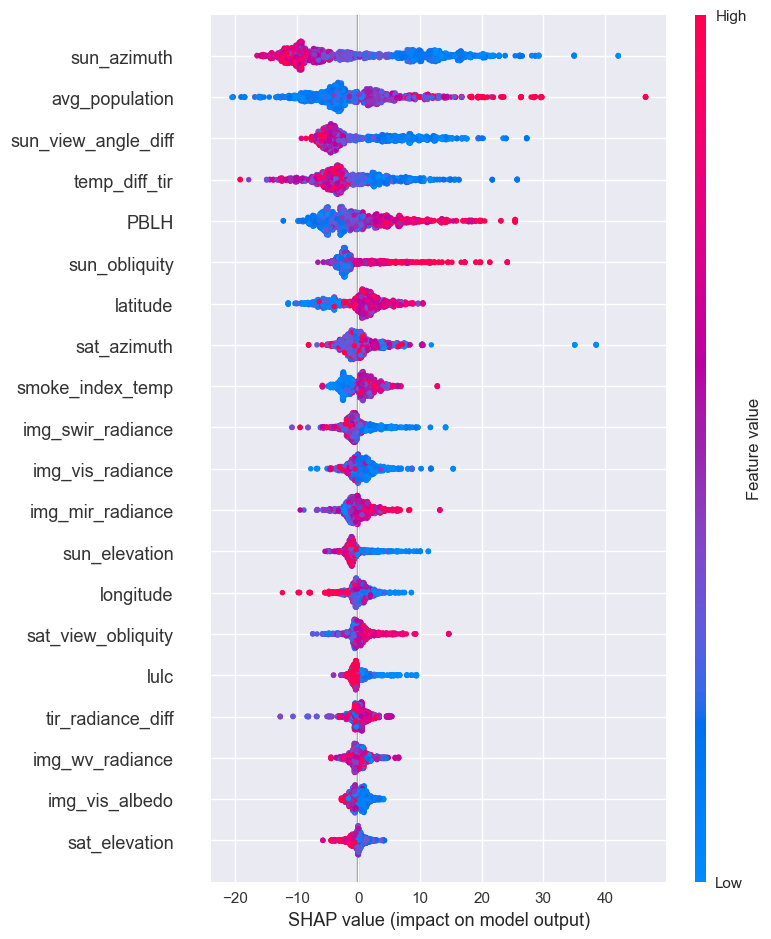

In [9]:
tqdm.write("📈 SHAP Analysis (No RFECV)...")

# Sample from X_test
X_shap_sample_df = X_test.sample(n=1500, random_state=42)

# SHAP Explainer
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_shap_sample_df)

# Summary Plot
shap.summary_plot(shap_values, features=X_shap_sample_df, feature_names=X_shap_sample_df.columns)


In [10]:
tqdm.write("📉 Error Clustering...")

# Calculate errors
errors = y_test - y_pred

# Use full feature set
error_df = pd.DataFrame(X_test.copy())
error_df['Error'] = errors.values

# Select top 10% largest absolute errors
error_cluster = error_df[error_df['Error'].abs() > np.percentile(abs(errors), 90)]

# Print descriptive stats
print("\n🔥 Top 10% Error Cluster:")
print(error_cluster.describe())


📉 Error Clustering...

🔥 Top 10% Error Cluster:
          latitude    longitude  img_mir_radiance  img_mir_temp  \
count  1940.000000  1940.000000       1940.000000   1940.000000   
mean     25.587027    80.605917          0.080497    304.319781   
std       4.746164     6.245944          0.024480      9.841171   
min       8.524112    71.393989          0.007826    255.810715   
25%      23.212474    76.791360          0.065757    300.578766   
50%      25.609324    77.064466          0.078419    305.039673   
75%      28.608282    85.211174          0.092140    309.118835   
max      34.065992    93.942308          0.142040    320.965363   

       img_swir_radiance  img_vis_radiance  smoke_index_temp  inversion_flag  \
count        1940.000000       1940.000000       1940.000000     1940.000000   
mean            1.312114          6.194712         64.693825        0.969588   
std             0.375746          4.639965         26.439460        0.171763   
min             0.507176    

In [ ]:
tqdm.write("🧠 Flagging Misleading Features...")

flagged = []

# Use full feature list instead of selected_features
feature_list = X_test.columns.tolist()

for i, feature in enumerate(feature_list):
    perm_val = perm_importances.loc[perm_importances['Feature'] == feature, 'Importance'].values[0]
    shap_val = np.mean(np.abs(shap_values[:, i]))  # index matches order of columns in X_test
    corr_err = error_df[feature].corr(error_df['Error'])

    if perm_val < 0.001 and shap_val > 0.01 and abs(corr_err) > 0.2:
        flagged.append((feature, perm_val, shap_val, corr_err))

# Convert to DataFrame
flagged_df = pd.DataFrame(flagged, columns=["Feature", "Permutation Importance", "SHAP", "Correlation with Error"])

print("\n🚨 Misleading Features (Low Perm, High SHAP, High Corr with Error):")
print(flagged_df)
